In [1]:
import cv2
import json
import pickle
import math
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader, random_split
from typing import List, Tuple
from tqdm import tqdm
from utils import softargmax_2d
from models import StackedHourglassCBAM
random.seed(20) # 10, 11, 12
device = torch.device("cuda:0")
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
with open("pickle/train.pkl", "rb") as f:
    train_data = pickle.load(f)
random.shuffle(train_data)

with open("pickle/val.pkl", "rb") as f:
    val_data = pickle.load(f)

with open("pickle/test.pkl", "rb") as f:
    test_data = pickle.load(f)

print(len(train_data))
print(len(val_data))
print(len(test_data))

2483
310
311


In [3]:
def generate_heatmap(size_hw: Tuple[int, int], center_xy: Tuple[float, float], sigma: float = 2.0):
    """Create a single 2D gaussian heatmap (H,W) with center (x,y) in pixel coords."""
    W, H = size_hw[1], size_hw[0]
    y = torch.arange(H, dtype=torch.float32)
    x = torch.arange(W, dtype=torch.float32)
    yy, xx = torch.meshgrid(y, x, indexing="ij")
    cx, cy = center_xy
    hm = torch.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * sigma ** 2))
    return hm

In [4]:
#LABELS = ("R1", "R2", "R3", "R4")

LABELS = (
    "R1", "R2", "R3", "R4"
)

class CustomDataset(Dataset):
    def __init__(self, data, image_size=(512, 256), heatmap_size=(128, 64), sigma=2, train=False):
        self.data = data
        self.image_size = image_size
        self.heatmap_size = heatmap_size
        self.sigma = sigma
        self.train = train

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image_path, keypoints = self.data[idx]
        image_array = np.fromfile(image_path, dtype=np.uint8)
        image = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Failed to read image at {image_path}")
        H, W = image.shape

        if self.train:
            
            if random.random() < 0.5:
                clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
                image = clahe.apply(image)
            # Brightness augmentation
            if random.random() < 0.5:
                factor = random.uniform(0.9, 1.1)  # brightness factor
                image = np.clip(image * factor, 0, 255).astype(np.uint8)

            if random.random() < 0.5:
                if random.random() < 0.5:
                    #print(f"SHARPEN")
                    kernel = np.array([[0, -1, 0],
                                [-1, 5, -1],
                                [0, -1, 0]])
                    
                    sharpened  = cv2.filter2D(image, -1, kernel)
                    alpha = random.uniform(0.1, 0.4)  # blend factor
                    image = cv2.addWeighted(sharpened, alpha, image, 1 - alpha, 0)
            
                else:
                    #print(f"BLUR")
                    ksize = random.choice([3, 5])
                    sigmaX = random.uniform(0.3, 1.0)
                    image = cv2.GaussianBlur(image, (ksize, ksize), sigmaX=sigmaX)


        resized_image = cv2.resize(image, (self.image_size[1], self.image_size[0]))

        scale_x = self.heatmap_size[1] / W
        scale_y = self.heatmap_size[0] / H

        keypoints = [keypoints[l] for l in LABELS]
        keypoints = np.array([(x * scale_x, (H - y) * scale_y) for x, y in keypoints], dtype=np.float32)
        
        image_tensor = torch.from_numpy(resized_image).float().unsqueeze(0) / 255.0
        keypoint_tensor = torch.from_numpy(keypoints)
        heatmap_tensor = torch.stack([generate_heatmap(self.heatmap_size, kp, sigma = self.sigma) for kp in keypoints])
        meta = {"image_path": image_path}

        return image_tensor, keypoint_tensor, heatmap_tensor, meta

In [5]:
batch_size = 32
image_size = (512, 256)
heatmap_size = (128, 64)

train_dataset = CustomDataset(
    data=train_data,
    image_size=image_size,
    heatmap_size=heatmap_size,
    sigma=2,
    train=True
)

val_dataset = CustomDataset(
    data=val_data,
    image_size=image_size,
    heatmap_size=heatmap_size,
    sigma=2,
    train=False
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

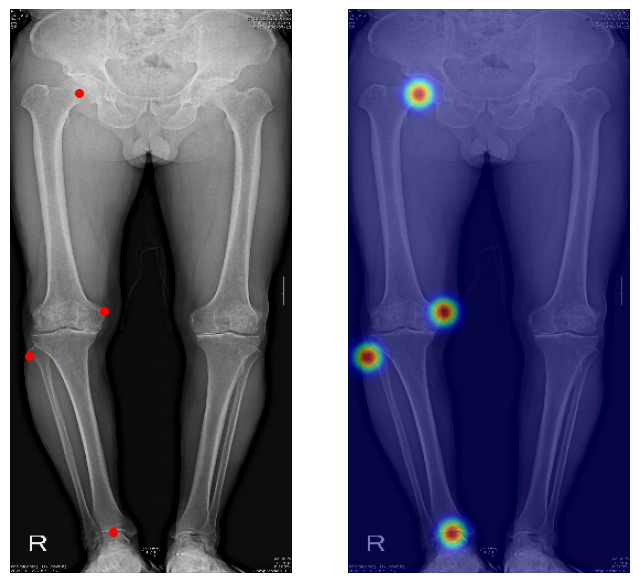

In [13]:
img, gt_kps, gt_hmps, meta = val_dataset[6]

img = img.squeeze().numpy()

gt_kps = gt_kps.numpy()
gt_kps[:, 0] *= 256/64
gt_kps[:, 1] *= 512/128

gt_hmps = gt_hmps.numpy()
cgt_hmps = np.max(gt_hmps, axis=0)
rgt_hmps = cv2.resize(cgt_hmps, (256, 512))

fig, axes = plt.subplots(1, 2, figsize=(8, 8))

axes[0].imshow(img, cmap='gray')
axes[0].scatter(gt_kps[:, 0], gt_kps[:, 1], c='red', marker='o', s=30)
axes[0].axis('off')

axes[1].imshow(img, cmap='gray')
axes[1].imshow(rgt_hmps, cmap='jet', alpha=0.5)
axes[1].axis('off')

plt.show()

In [15]:
model = StackedHourglassCBAM(num_keypoints=4, num_stacks=2, depth=4, channels=256, in_ch=1).to(device) # 12
x = torch.rand(1, 1, 512, 256).to(device)
outs = model(x)
print([out.shape for out in outs])
print(f"Model params: {sum(p.numel() for p in model.parameters())}")

[torch.Size([1, 4, 128, 64]), torch.Size([1, 4, 128, 64])]
Model params: 6728004


In [16]:
class AdaptiveWingLoss(nn.Module):
    """
    Adaptive Wing Loss for heatmap regression.

    Paper: "Adaptive Wing Loss for Robust Face Alignment via Heatmap Regression" (ICCV 2019)

    Args:
        alpha (float): curvature control (>2), paper uses 2.1
        omega (float): scaling factor, paper uses 14.0
        epsilon (float): small constant, paper uses 1.0
        theta (float): transition between nonlinear / linear, paper uses 0.5
        reduction (str): 'mean', 'sum', or 'none'
    """
    def __init__(
        self,
        alpha: float = 2.1,
        omega: float = 14.0,
        epsilon: float = 1.0,
        theta: float = 0.5,
        reduction: str = "mean",
    ):
        super().__init__()
        assert reduction in ("mean", "sum", "none")
        self.alpha = alpha
        self.omega = omega
        self.epsilon = epsilon
        self.theta = theta
        self.reduction = reduction

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        """
        pred:   predicted heatmaps, shape (N, C, H, W) or similar
        target: ground truth heatmaps, same shape, values typically in [0, 1]
        """
        if pred.shape != target.shape:
            raise ValueError(f"Shape mismatch: pred {pred.shape}, target {target.shape}")

        # For AMP stability, compute in float32
        y_hat = pred.float()
        y = target.float()

        omega = self.omega
        theta = self.theta
        eps = self.epsilon
        alpha = self.alpha

        # |y - y^|
        delta = torch.abs(y - y_hat)

        # exponent = α - y  (adaptive to GT intensity)
        exponent = alpha - y  # same shape as y

        # Prepare base tensor for (θ/ε)^(α - y)
        theta_over_eps = theta / eps
        base = torch.full_like(y, theta_over_eps)

        t = torch.pow(base, exponent)  # (θ/ε)^(α - y)

        # A and C for linear branch (ensuring continuity & smoothness)
        A = omega * (1.0 / (1.0 + t)) * exponent * torch.pow(base, exponent - 1.0) * (1.0 / eps)
        C = theta * A - omega * torch.log(1.0 + t)

        # Mask: small vs large error
        small_err = delta < theta

        # Nonlinear part: ω * log(1 + (|y - y^| / ε)^(α - y))
        delta_over_eps = delta / eps
        loss_small = omega * torch.log(1.0 + torch.pow(delta_over_eps, exponent))

        # Linear part: A * |y - y^| - C
        loss_large = A * delta - C

        loss = torch.where(small_err, loss_small, loss_large)

        # reduction
        if self.reduction == "mean":
            loss = loss.mean()
        elif self.reduction == "sum":
            loss = loss.sum()
        # else: 'none' → return per-pixel loss

        # Match original dtype (useful with AMP)
        return loss.to(pred.dtype)

In [17]:
train_losses, val_losses = [], []

num_epochs = 100
warmup_epochs = 3
base_lr = 3e-4 #3e-4
weight_decay = 1e-4
grad_clip_norm  = 1.0
use_amp = True
model_path = "saved/hourglass_cbam_mse[roi].pth"

criterion = AdaptiveWingLoss(
    alpha=2.1,
    omega=14.0,
    epsilon=1.0,
    theta=0.5,
    reduction="mean",
)
#criterion = nn.MSELoss()
#criterion = nn.BCEWithLogitsLoss()
#criterion = FocalBCELoss(alpha=0.25, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)
scaler = GradScaler(enabled=use_amp)

def lr_lambda(current_epoch):
    if current_epoch < warmup_epochs:
        # Linear warmup
        return float(current_epoch + 1) / float(warmup_epochs)
    else:
        # Cosine decay
        progress = (current_epoch - warmup_epochs) / float(num_epochs - warmup_epochs)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)

best_val_loss = float('inf')
epochs_no_improve = 0
early_stopping_patience = 5

for epoch in range(num_epochs):
    model.train()

    train_loss = 0

    for images, _, heatmaps, _ in tqdm(train_loader, desc=f"[Epoch {epoch+1}/{num_epochs}] Training"):
        images = images.to(device, non_blocking=True)
        heatmaps = heatmaps.to(device, non_blocking=True).float()

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=use_amp):
            outputs = model(images)
            #loss = sum(w * criterion(o, heatmaps) for w, o in zip(head_weights, outputs))
            loss = sum(criterion(o, heatmaps) for o in outputs) / len(outputs)

        if use_amp:
            scaler.scale(loss).backward()
            # Unscale gradients before clipping
            scaler.unscale_(optimizer)
            # Clip the gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
            # Then optimizer step
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
            optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    pix_errs = []
    with torch.no_grad():
        for images, keypoints, heatmaps, _ in tqdm(val_loader, desc=f"[Epoch {epoch+1}/{num_epochs}] Validation"):
            images = images.to(device, non_blocking=True)
            gt_xy = keypoints.to(device, non_blocking=True).float()
            heatmaps = heatmaps.to(device, non_blocking=True).float()

            with autocast(enabled=use_amp):
                outputs = model(images)
                #loss = sum(w * criterion(o, heatmaps) for w, o in zip(head_weights, outputs))
                loss = sum(criterion(o, heatmaps) for o in outputs) / len(outputs)
                
                #loss = criterion(outputs, heatmaps)
                #pred_xy = decode_argmax(outputs[-1])
                #batch_err = pck_like_err(pred_xy, gt_xy)
                #val_pix_err += batch_err.item()
                pred_xy = softargmax_2d(outputs[-1], beta=100.0)
            
            pix_errs.append(torch.linalg.vector_norm(pred_xy - gt_xy, dim=-1))
            val_loss += loss.item()

    val_pix_errs = torch.cat(pix_errs, dim=0).mean(dim=0)
    val_loss /= len(val_loader)

    scheduler.step()
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} ➤ Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}") # | mean_pixel_err: {val_pix_err:.2f}
    print(f"val_pix_errs:\n{val_pix_errs.cpu().numpy()}")
    # Early Stopping & Save Best
    if val_loss < best_val_loss:
        print(f"🟢 New best model (val_loss: {val_loss:.6f} < {best_val_loss:.6f}) — saving to {model_path}")
        best_val_loss = val_loss
        torch.save(model.state_dict(), model_path)
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"🔴 No improvement for {epochs_no_improve} epoch(s)")
    
    if epochs_no_improve >= early_stopping_patience:
        print("⏹ Early stopping triggered.")
        break

/tmp/ipykernel_3114/830088695.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)
[Epoch 1/100] Training:   0%|          | 0/78 [00:00<?, ?it/s]/tmp/ipykernel_3114/830088695.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
[Epoch 1/100] Validation:   0%|          | 0/10 [00:00<?, ?it/s]/tmp/ipykernel_3114/830088695.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
[Epoch 1/100] Validation: 100%|██████████| 10/10 [00:08<00:00,  1.20it/s]


Epoch 1/100 ➤ Train Loss: 0.232152 | Val Loss: 0.088330
val_pix_errs:
[76.905106 30.979738 43.999893 40.543926]
🟢 New best model (val_loss: 0.088330 < inf) — saving to saved/hourglass_cbam_mse[roi].pth


[Epoch 2/100] Validation: 100%|██████████| 10/10 [00:08<00:00,  1.15it/s]


Epoch 2/100 ➤ Train Loss: 0.027016 | Val Loss: 0.022595
val_pix_errs:
[38.06547   16.876299  23.82595    4.3671174]
🟢 New best model (val_loss: 0.022595 < 0.088330) — saving to saved/hourglass_cbam_mse[roi].pth


[Epoch 3/100] Validation: 100%|██████████| 10/10 [00:08<00:00,  1.21it/s]


...

Epoch 36/100 ➤ Train Loss: 0.000587 | Val Loss: 0.002923
val_pix_errs:
[0.6856519 0.799313  0.3845122 0.620749 ]
🔴 No improvement for 3 epoch(s)


[Epoch 37/100] Validation: 100%|██████████| 10/10 [00:08<00:00,  1.14it/s]


Epoch 37/100 ➤ Train Loss: 0.000489 | Val Loss: 0.002767
val_pix_errs:
[0.4016508 0.8092912 0.5688131 0.6247191]
🔴 No improvement for 4 epoch(s)


[Epoch 38/100] Validation: 100%|██████████| 10/10 [00:08<00:00,  1.15it/s]

Epoch 38/100 ➤ Train Loss: 0.000423 | Val Loss: 0.001794
val_pix_errs:
[0.4045656  0.7664285  0.55983245 0.5380423 ]
🔴 No improvement for 5 epoch(s)
⏹ Early stopping triggered.


In [12]:
train_losses, val_losses = [], []

num_epochs = 100
warmup_epochs = 3
base_lr = 3e-4 #3e-4
weight_decay = 1e-4
grad_clip_norm  = 1.0
use_amp = True
model_path = "saved/hourglass_cbam_mse[roi].pth"

criterion = nn.MSELoss()
#criterion = nn.BCEWithLogitsLoss()
#criterion = FocalBCELoss(alpha=0.25, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)
scaler = GradScaler(enabled=use_amp)

def lr_lambda(current_epoch):
    if current_epoch < warmup_epochs:
        # Linear warmup
        return float(current_epoch + 1) / float(warmup_epochs)
    else:
        # Cosine decay
        progress = (current_epoch - warmup_epochs) / float(num_epochs - warmup_epochs)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)

best_val_loss = float('inf')
epochs_no_improve = 0
early_stopping_patience = 4

for epoch in range(num_epochs):
    model.train()

    train_loss = 0

    for images, _, heatmaps, _ in tqdm(train_loader, desc=f"[Epoch {epoch+1}/{num_epochs}] Training"):
        images = images.to(device, non_blocking=True)
        heatmaps = heatmaps.to(device, non_blocking=True).float()

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=use_amp):
            outputs = model(images)
            #loss = sum(w * criterion(o, heatmaps) for w, o in zip(head_weights, outputs))
            loss = sum(criterion(o, heatmaps) for o in outputs) / len(outputs)

        if use_amp:
            scaler.scale(loss).backward()
            # Unscale gradients before clipping
            scaler.unscale_(optimizer)
            # Clip the gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
            # Then optimizer step
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
            optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    pix_errs = []
    with torch.no_grad():
        for images, keypoints, heatmaps, _ in tqdm(val_loader, desc=f"[Epoch {epoch+1}/{num_epochs}] Validation"):
            images = images.to(device, non_blocking=True)
            gt_xy = keypoints.to(device, non_blocking=True).float()
            heatmaps = heatmaps.to(device, non_blocking=True).float()

            with autocast(enabled=use_amp):
                outputs = model(images)
                #loss = sum(w * criterion(o, heatmaps) for w, o in zip(head_weights, outputs))
                loss = sum(criterion(o, heatmaps) for o in outputs) / len(outputs)
                
                #loss = criterion(outputs, heatmaps)
                #pred_xy = decode_argmax(outputs[-1])
                #batch_err = pck_like_err(pred_xy, gt_xy)
                #val_pix_err += batch_err.item()
                pred_xy = softargmax_2d(outputs[-1], beta=100.0)
            
            pix_errs.append(torch.linalg.vector_norm(pred_xy - gt_xy, dim=-1))
            val_loss += loss.item()

    val_pix_errs = torch.cat(pix_errs, dim=0).mean(dim=0)
    val_loss /= len(val_loader)

    scheduler.step()
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} ➤ Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}") # | mean_pixel_err: {val_pix_err:.2f}
    print(f"val_pix_errs:\n{val_pix_errs.cpu().numpy()}")
    # Early Stopping & Save Best
    if val_loss < best_val_loss:
        print(f"🟢 New best model (val_loss: {val_loss:.6f} < {best_val_loss:.6f}) — saving to {model_path}")
        best_val_loss = val_loss
        torch.save(model.state_dict(), model_path)
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"🔴 No improvement for {epochs_no_improve} epoch(s)")
    
    if epochs_no_improve >= early_stopping_patience:
        print("⏹ Early stopping triggered.")
        break

/tmp/ipykernel_2179/1514541738.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)
[Epoch 1/100] Training:   0%|          | 0/81 [00:00<?, ?it/s]/tmp/ipykernel_2179/1514541738.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
[Epoch 1/100] Validation:   0%|          | 0/21 [00:00<?, ?it/s]/tmp/ipykernel_2179/1514541738.py:75: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
[Epoch 1/100] Validation: 100%|██████████| 21/21 [00:17<00:00,  1.17it/s]


Epoch 1/100 ➤ Train Loss: 0.022000 | Val Loss: 0.007767
val_pix_errs:
[71.24653  57.045246 64.53492  73.349365]
🟢 New best model (val_loss: 0.007767 < inf) — saving to saved/hourglass_cbam_mse[roi]_fold_0.pth


[Epoch 2/100] Validation: 100%|██████████| 21/21 [00:18<00:00,  1.15it/s]


Epoch 2/100 ➤ Train Loss: 0.002303 | Val Loss: 0.002588
val_pix_errs:
[52.856556 55.552643 62.18553  68.62669 ]
🟢 New best model (val_loss: 0.002588 < 0.007767) — saving to saved/hourglass_cbam_mse[roi]_fold_0.pth


[Epoch 3/100] Validation: 100%|██████████| 21/21 [00:17<00:00,  1.17it/s]


...

Epoch 10/100 ➤ Train Loss: 0.000168 | Val Loss: 0.000608
val_pix_errs:
[2.553199   1.6033292  1.5751176  0.98293674]
🔴 No improvement for 2 epoch(s)


[Epoch 11/100] Validation: 100%|██████████| 21/21 [00:17<00:00,  1.19it/s]


Epoch 11/100 ➤ Train Loss: 0.000152 | Val Loss: 0.001230
val_pix_errs:
[2.9495614 2.283911  1.7286091 1.2047178]
🔴 No improvement for 3 epoch(s)


[Epoch 12/100] Validation: 100%|██████████| 21/21 [00:18<00:00,  1.12it/s]

Epoch 12/100 ➤ Train Loss: 0.000129 | Val Loss: 0.000804
val_pix_errs:
[1.8127415 1.2830553 1.1576313 0.9844038]
🔴 No improvement for 4 epoch(s)
⏹ Early stopping triggered.


dataset/2021_01월/1016 추안순_KP/M2/추안순1.jpg
torch.Size([1, 4, 128, 64])


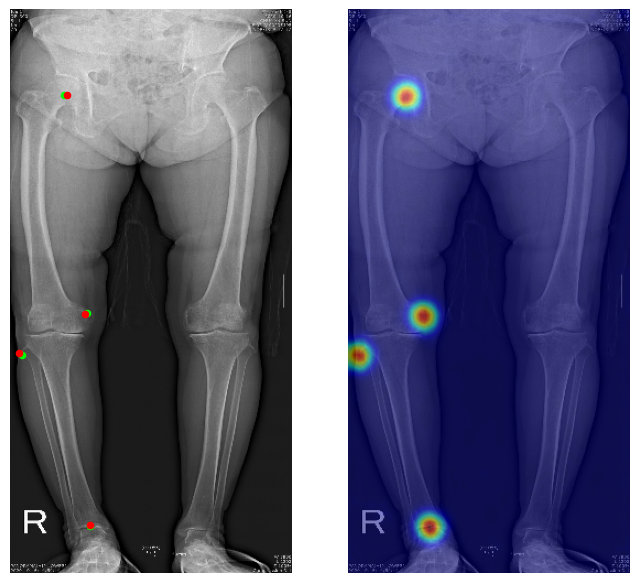

In [13]:
idx = 0
img, gt_kps, gt_hmps, meta = val_dataset[idx]

print(meta['image_path'])

with torch.no_grad():
    x = img.unsqueeze(0).to(device)
    outs = model(x)

p_hmps = outs[-1]
print(p_hmps.shape)
p_kps = softargmax_2d(p_hmps, beta=100.0)
p_kps = p_kps.squeeze().cpu().numpy()

p_kps[:, 0] *= 256 / 64
p_kps[:, 1] *= 512 / 128

p_hmps = p_hmps.squeeze().cpu().numpy()
p_hmps = np.max(p_hmps, axis=0)
p_hmps = cv2.resize(p_hmps, (256, 512))

img = img.squeeze().numpy()
gt_kps = gt_kps.numpy()

gt_kps[:, 0] *= 256/64
gt_kps[:, 1] *= 512/128

fig, axes = plt.subplots(1, 2, figsize=(8, 8))

axes[0].imshow(img, cmap='gray')
axes[0].scatter(gt_kps[:, 0], gt_kps[:, 1], c='lime', marker='o', s=20)
axes[0].scatter(p_kps[:, 0], p_kps[:, 1], c='red', marker='o', s=20)
 
axes[1].imshow(img, cmap='gray')
axes[1].imshow(p_hmps, cmap='jet', alpha=0.5)

for ax in axes:
    ax.axis('off')
plt.show()

In [ ]:
idx = 0
img, gt_kps, gt_hmps, meta = val_dataset[idx]

print(meta['image_path'])

with torch.no_grad():
    x = img.unsqueeze(0).to(device)
    outs = model(x)
    #p_hmps_up = F.interpolate(p_hmps[-1], size=(512, 512), mode='bilinear', align_corners=False)

p_hmp = outs[-1]
p_kps = softargmax_2d(p_hmp, beta=100.0)  # (1, 12, 2)
p_kps = p_kps.squeeze().cpu().numpy()

p_kps[0] *= 384 / 96
p_kps[1] *= 384 / 96

p_hmp = p_hmp.squeeze().cpu().numpy()
r_hmp = cv2.resize(p_hmp, (384, 384))

img = img.squeeze().numpy()
gt_kps = gt_kps.numpy()
gt_kps[0] *= 384 / 96
gt_kps[1] *= 384 / 96

dist = np.linalg.norm(gt_kps - p_kps)

print(dist)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img, cmap='gray')
axes[0].scatter(gt_kps[0], gt_kps[1], c='lime', marker='o', s=20)
axes[0].scatter(p_kps[0], p_kps[1], c='red', marker='o', s=20)
 
axes[1].imshow(img, cmap='gray')
axes[1].imshow(r_hmp, cmap='jet', alpha=0.5)

for ax in axes:
    ax.axis('off')
plt.show()

# [2.5204163 1.0026113 2.8162513 8.15204   1.1367732 8.030139  7.6611757
#  3.1140485 5.911936  4.752094  8.985992  7.1919   ]